# 02 – Data Understanding: Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de subempleo por insuficiencia de horas – EPEN 2024 (INEI Perú)  
**Universo analítico:** Personas ocupadas, residentes, de 14 años a más, en Lima Metropolitana con respuesta válida en `P209H`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# ─── Rutas ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = os.getcwd()
PROJECT_DIR   = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
SNAPSHOT_PATH = os.path.join(PROJECT_DIR, 'data', 'raw', 'epen2024_raw_snapshot.csv')

print(f'Snapshot: {SNAPSHOT_PATH}')
print(f'Existe:   {os.path.exists(SNAPSHOT_PATH)}')

df_raw = pd.read_csv(SNAPSHOT_PATH, encoding='utf-8-sig', low_memory=False)
print(f'Raw: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')

# ─── Convertir columnas clave a numérico (pueden venir como string desde CSV) ─
df_raw['C208_num']    = pd.to_numeric(df_raw['C208'], errors='coerce')
df_raw['OCUP300_num'] = pd.to_numeric(
    df_raw['OCUP300'].replace(r'^\s*$', np.nan, regex=True), errors='coerce')
df_raw['P209H_clean'] = pd.to_numeric(
    df_raw['P209H'].replace(r'^\s*$', np.nan, regex=True), errors='coerce')

# ─── Filtros del universo analítico ───────────────────────────────────────────
mask = (
    (df_raw['RESIDENT'] == 1) &
    (df_raw['C208_num'] >= 14) &
    (df_raw['OCUP300_num'] == 1) &
    (df_raw['P209H_clean'].isin([1, 2]))
)
df = df_raw[mask].copy()

# ─── Variable objetivo ────────────────────────────────────────────────────────
df['target_subempleo_horas'] = (df['P209H_clean'] == 1).astype(int)

# Convertir variables numéricas clave
for col in ['C208_num', 'C318_T', 'C328_T', 'whoraT', 'C331', 'INGTOT', 'INGTOTP', 'ingtrabw']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Reemplazar códigos especiales de missing por NaN
df['INGTOT']   = df['INGTOT'].replace(999999, np.nan)
df['INGTOTP']  = df['INGTOTP'].replace(999999, np.nan)
df['ingtrabw'] = df['ingtrabw'].replace(999999, np.nan)
df['C318_T']   = df['C318_T'].replace(99, np.nan)
df['whoraT']   = df['whoraT'].replace(999, np.nan)

n = df.shape[0]
print(f'\nUniverso analítico: {n:,} personas ocupadas con P209H válido')
print(f'Subempleados por horas (target=1): {df["target_subempleo_horas"].sum():,} '
      f'({df["target_subempleo_horas"].mean()*100:.1f}%)')
df.head()

Snapshot: g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Machine Learning\TrabajoFinal\clonProyecto\ML_PROYECTO_26_1\ml_project\data\raw\epen2024_raw_snapshot.csv
Existe:   True
Raw: 52,251 filas × 132 columnas

Universo analítico: 24,054 personas ocupadas con P209H válido
Subempleados por horas (target=1): 5,990 (24.9%)


,ANIO,MES,CONGLOMERADO,MUESTRA,SELVIV,HOGAR,REGION,LLAVE_PANEL,ESTRATO,C201,...,ingtrabw,RESIDENT,fa_ond24,fa_efm24,fa_amj24,fa_jas24,C208_num,OCUP300_num,P209H_clean,target_subempleo_horas
0,2024,10,18117,2,61,1,1,2.024102e+17,1,1,...,1367.0,1,700.400712309202,NaN,NaN,NaN,60.0,1.0,2.0,0
1,2024,10,18117,2,61,1,1,2.024102e+17,1,2,...,1534.0,1,700.400712309202,NaN,NaN,NaN,49.0,1.0,1.0,1
3,2024,10,1823302,1,59,1,1,2.024102e+19,1,1,...,1400.0,1,896.469463880284,NaN,NaN,NaN,52.0,1.0,2.0,0
4,2024,10,1823302,1,59,1,1,2.024102e+19,1,2,...,1516.0,1,844.036079933212,NaN,NaN,NaN,51.0,1.0,2.0,0
5,2024,10,1823302,1,60,1,1,2.024102e+19,1,1,...,1083.0,1,1017.64626579777,NaN,NaN,NaN,43.0,1.0,2.0,0


## 1. Distribución del target

Balance de clases de `target_subempleo_horas` (1 = subempleado por horas · 0 = no subempleado).

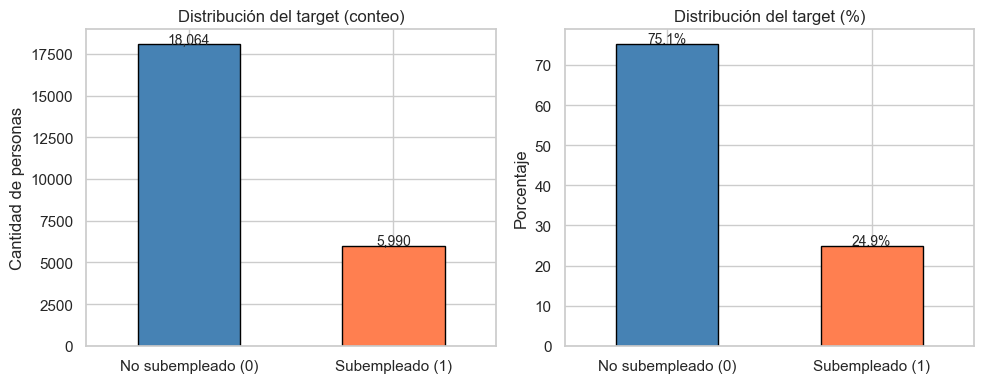

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteo = df['target_subempleo_horas'].value_counts().sort_index()
conteo.index = ['No subempleado (0)', 'Subempleado (1)']
conteo.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black', rot=0)
axes[0].set_title('Distribución del target (conteo)')
axes[0].set_ylabel('Cantidad de personas')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10)

pct = conteo / conteo.sum() * 100
pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black', rot=0)
axes[1].set_title('Distribución del target (%)')
axes[1].set_ylabel('Porcentaje')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 2. Variables numéricas clave

                         count     mean      std   min     25%     50%  \
Edad                   24054.0    42.02    14.79  14.0    30.0    41.0   
Horas ocup. principal  24053.0    40.78    18.84   0.0    30.0    42.0   
Horas totales          24054.0    44.50    17.91   2.0    36.0    46.0   
Ingreso total          23280.0  2047.38  2064.66   3.0  1025.0  1516.0   
Ingreso principal      23280.0  1976.75  1956.62   3.0  1025.0  1500.0   

                          75%      max  
Edad                     53.0     92.0  
Horas ocup. principal    50.0    112.0  
Horas totales            54.0    118.0  
Ingreso total          2500.0  40000.0  
Ingreso principal      2400.0  40000.0  


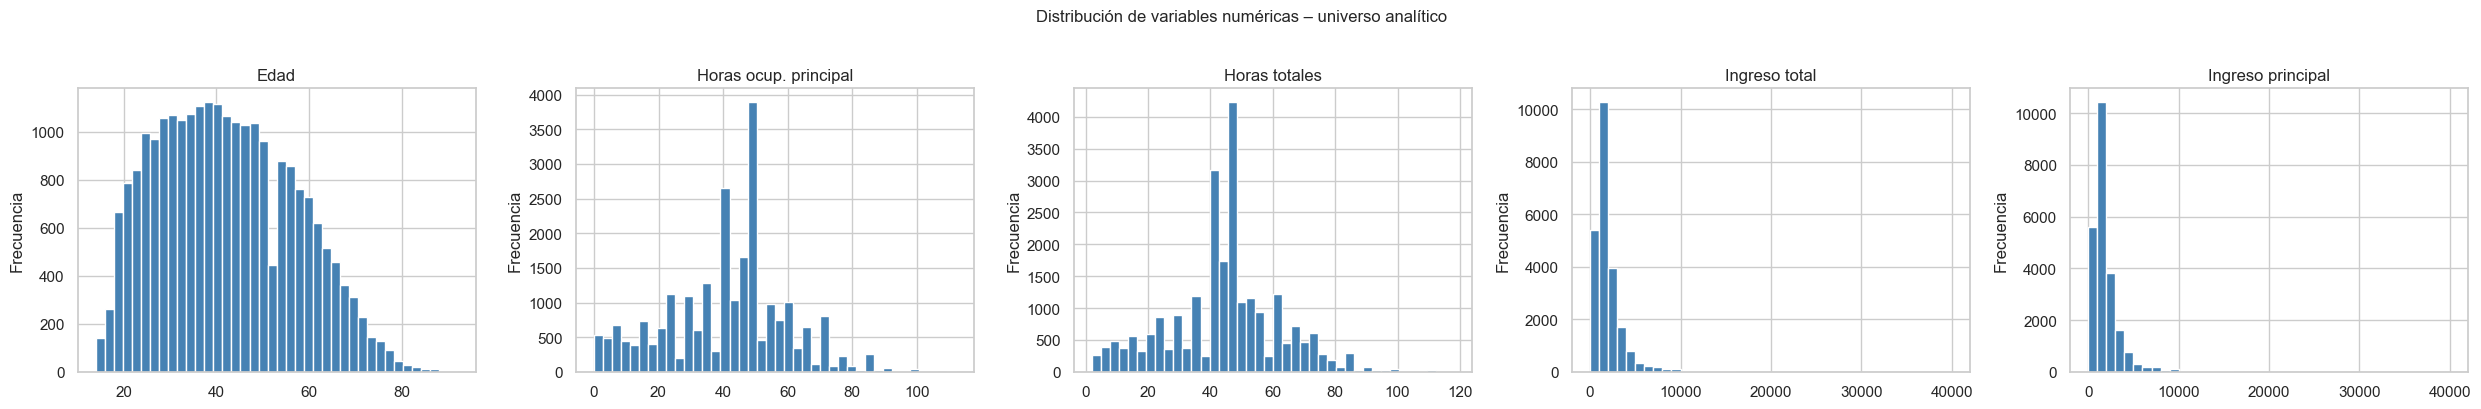

In [3]:
NUM_VARS = {
    'C208_num': 'Edad',
    'C318_T':   'Horas ocup. principal',
    'whoraT':   'Horas totales',
    'INGTOT':   'Ingreso total',
    'INGTOTP':  'Ingreso principal',
}

vars_num_disp = {k: v for k, v in NUM_VARS.items() if k in df.columns}
print(df[list(vars_num_disp.keys())].describe().rename(columns=vars_num_disp).T.round(2))

fig, axes = plt.subplots(1, len(vars_num_disp), figsize=(5 * len(vars_num_disp), 4))
if len(vars_num_disp) == 1:
    axes = [axes]
for ax, (col, label) in zip(axes, vars_num_disp.items()):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de variables numéricas – universo analítico', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Variables categóricas clave

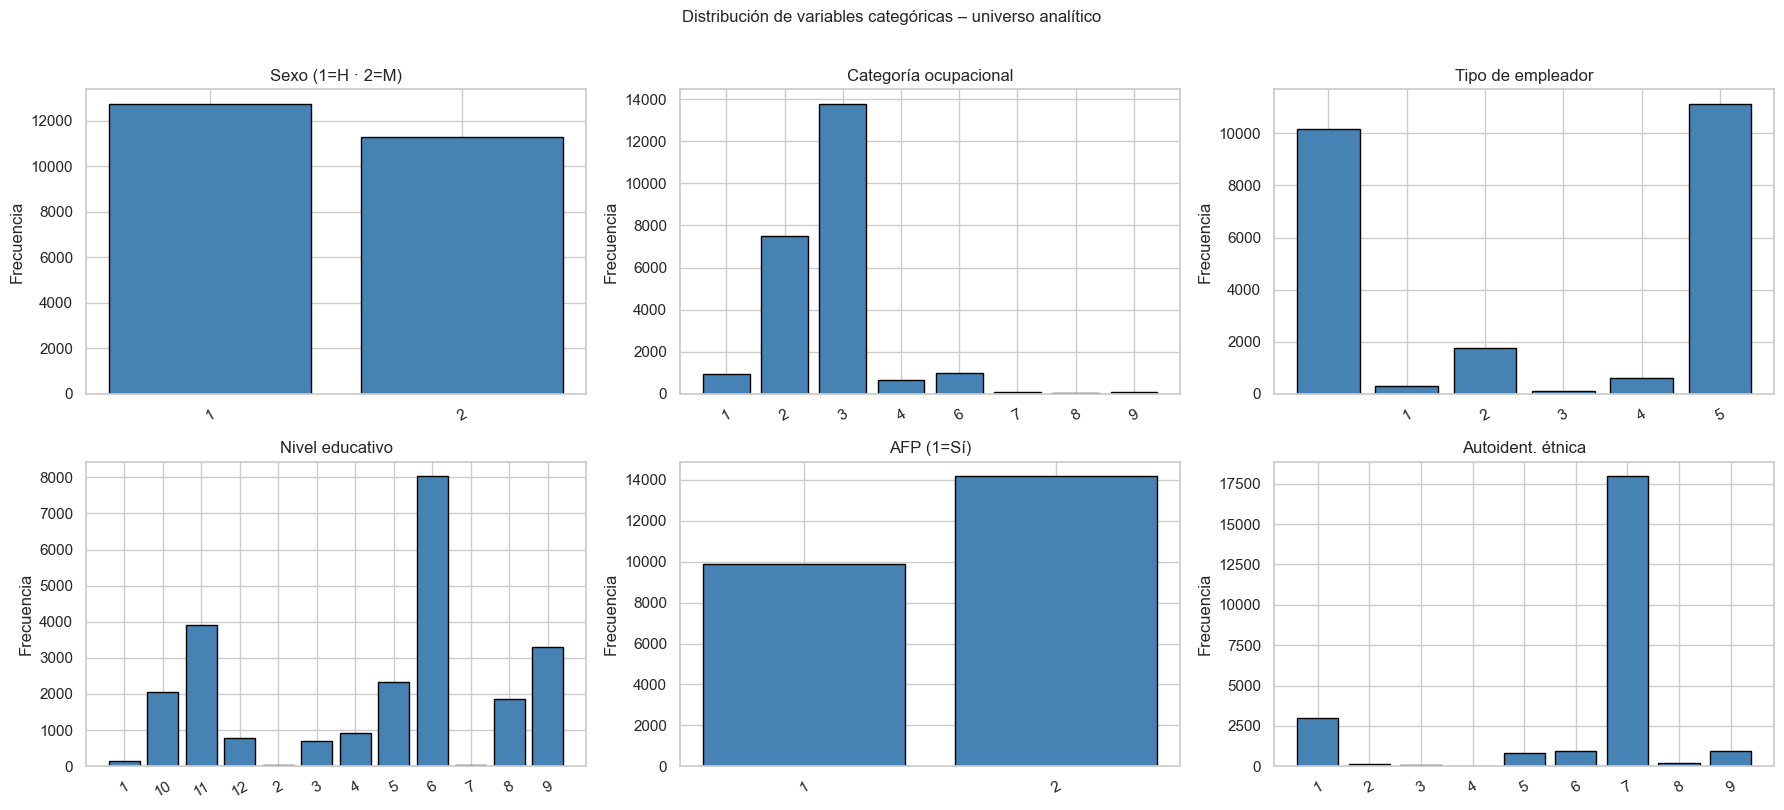

In [4]:
CAT_VARS = {
    'C207':  'Sexo (1=H · 2=M)',
    'C310':  'Categoría ocupacional',
    'C311':  'Tipo de empleador',
    'C366':  'Nivel educativo',
    'C364_1':'AFP (1=Sí)',
    'C377':  'Autoident. étnica',
}

vars_cat_disp = {k: v for k, v in CAT_VARS.items() if k in df.columns}
n_plots = len(vars_cat_disp)
n_cols  = 3
n_rows  = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, (col, label) in zip(axes, vars_cat_disp.items()):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='black')
    ax.set_title(label)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Distribución de variables categóricas – universo analítico', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4. Relación de variables con el target

Comparación de la distribución de edad y horas trabajadas entre subempleados y no subempleados.

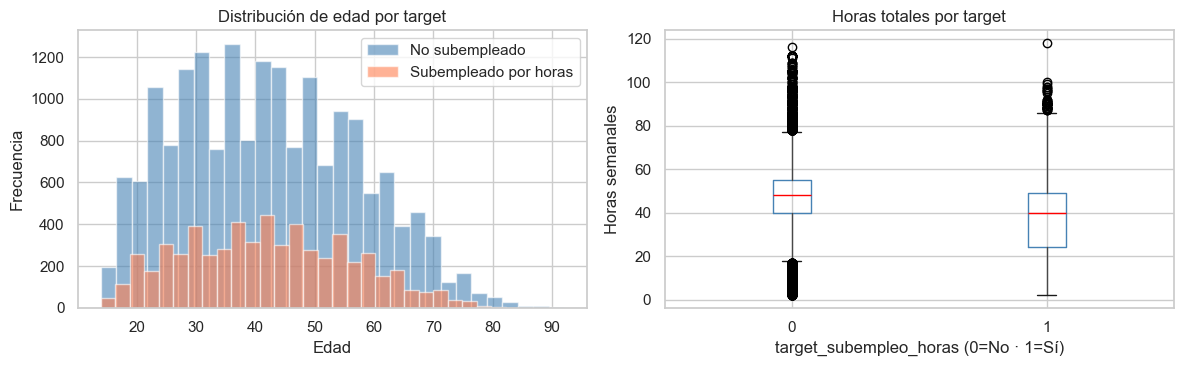

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for val, label, color in [(0, 'No subempleado', 'steelblue'), (1, 'Subempleado por horas', 'coral')]:
    axes[0].hist(df.loc[df['target_subempleo_horas'] == val, 'C208_num'].dropna(),
                 bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title('Distribución de edad por target')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

df.boxplot(column='whoraT', by='target_subempleo_horas', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('Horas totales por target')
axes[1].set_xlabel('target_subempleo_horas (0=No · 1=Sí)')
axes[1].set_ylabel('Horas semanales')
plt.suptitle('')
plt.tight_layout()
plt.show()

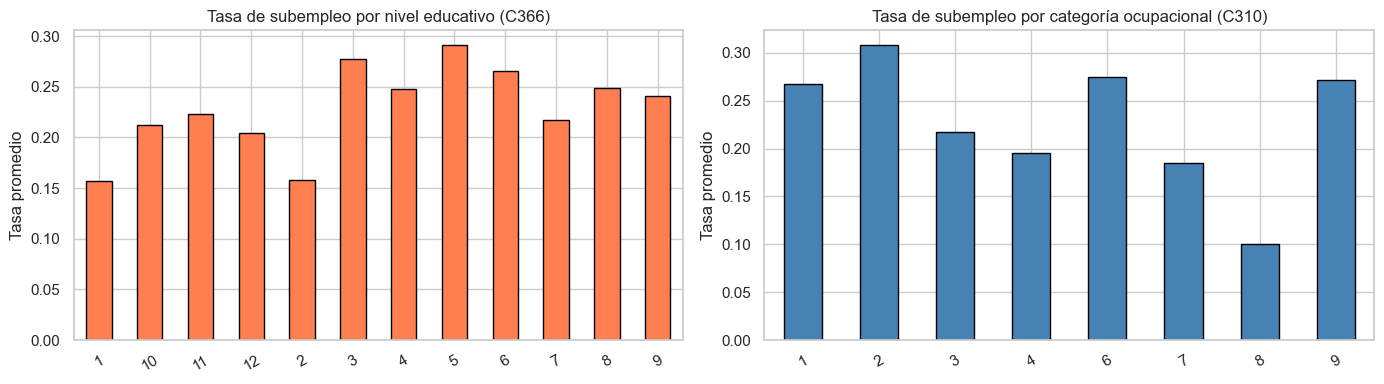

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tasa_educ = (df.groupby('C366')['target_subempleo_horas']
               .mean()
               .sort_index()
               .rename({1:'Sin nivel',2:'Inicial',3:'Pri inc',4:'Pri comp',
                        5:'Sec inc',6:'Sec comp',7:'Básica esp',
                        8:'SupNU inc',9:'SupNU comp',10:'SupU inc',
                        11:'SupU comp',12:'Maest/Doc'}))
tasa_educ.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black', rot=30)
axes[0].set_title('Tasa de subempleo por nivel educativo (C366)')
axes[0].set_ylabel('Tasa promedio')
axes[0].set_xlabel('')

tasa_ocup = (df.groupby('C310')['target_subempleo_horas']
               .mean()
               .sort_index()
               .rename({1:'Empleador',2:'Independ.',3:'Empl/obrero',
                        4:'Ayud.neg.fam.',5:'Ayud.empl.fam.',
                        6:'Trab.hogar',7:'Pract.rem.',8:'Pract.s/rem.'}))
tasa_ocup.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black', rot=30)
axes[1].set_title('Tasa de subempleo por categoría ocupacional (C310)')
axes[1].set_ylabel('Tasa promedio')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

## 5. Correlación entre variables numéricas

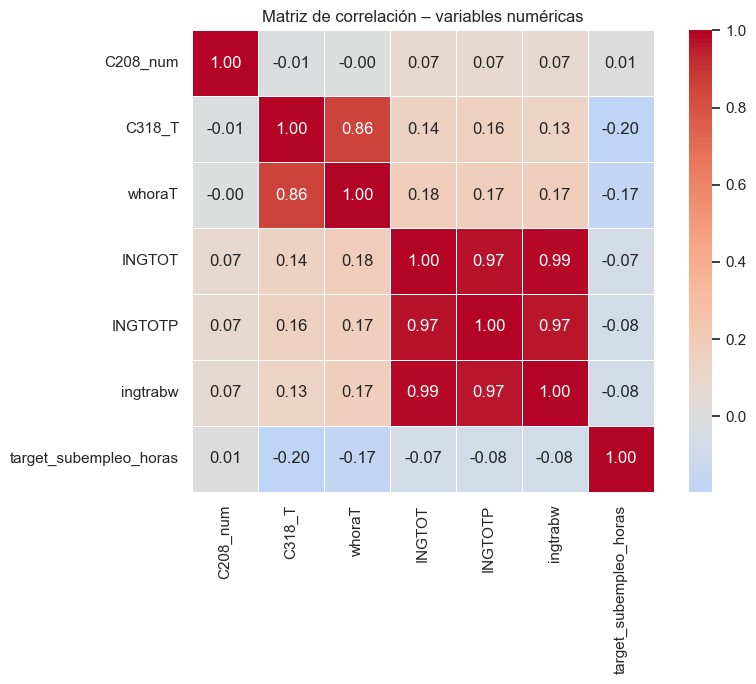

In [7]:
NUM_CORR = [c for c in ['C208_num', 'C318_T', 'whoraT', 'INGTOT', 'INGTOTP', 'ingtrabw',
                         'target_subempleo_horas'] if c in df.columns]
corr = df[NUM_CORR].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True,
            xticklabels=NUM_CORR, yticklabels=NUM_CORR)
plt.title('Matriz de correlación – variables numéricas')
plt.tight_layout()
plt.show()

## 6. Valores faltantes en el universo analítico

Variable  Nulos  Pct_nulo
  C328_T  21604     89.81
    C331  20614     85.70
  INGTOT    774      3.22
 INGTOTP    774      3.22
ingtrabw    774      3.22
    C312      0      0.00
    C311      0      0.00
    C310      0      0.00
    C207      0      0.00
C208_num      0      0.00
  C318_T      1      0.00
    C313      0      0.00
    C317      0      0.00
  whoraT      0      0.00
    C366      0      0.00
 SEGURO1      0      0.00
  C364_1      0      0.00
  C364_2      0      0.00
    C376      0      0.00
    C377      0      0.00
fa_son24     -1     -1.00


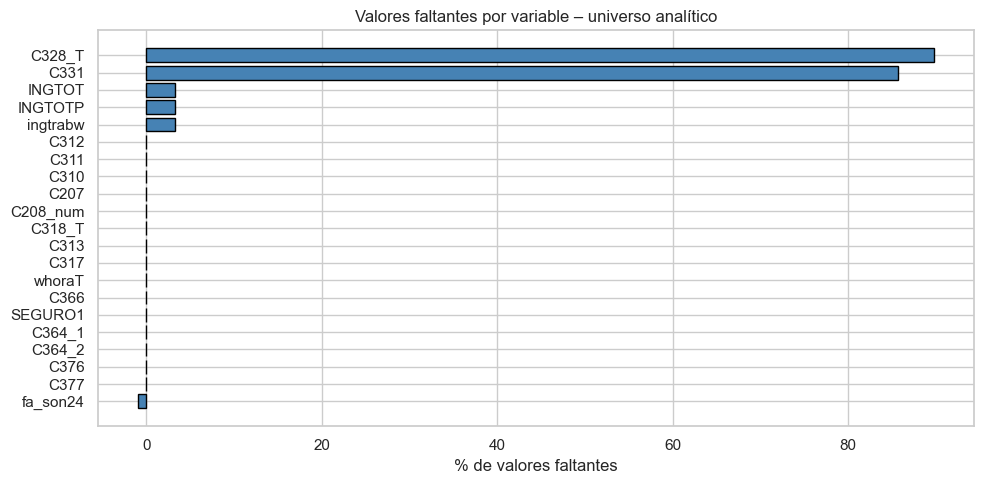

In [8]:
VARS_REL = ['C208_num', 'C207', 'C310', 'C311', 'C312', 'C313',
            'C317', 'C318_T', 'C328_T', 'whoraT', 'C331',
            'INGTOT', 'INGTOTP', 'ingtrabw', 'C366', 'SEGURO1',
            'C364_1', 'C364_2', 'C376', 'C377', 'fa_son24']

miss_df = pd.DataFrame({
    'Variable': VARS_REL,
    'Nulos':    [df[c].isna().sum() if c in df.columns else -1 for c in VARS_REL],
    'Pct_nulo': [(df[c].isna().sum() / len(df) * 100).round(2) if c in df.columns else -1 for c in VARS_REL],
})
miss_df = miss_df.sort_values('Pct_nulo', ascending=False)
print(miss_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(miss_df['Variable'], miss_df['Pct_nulo'], color='steelblue', edgecolor='black')
plt.xlabel('% de valores faltantes')
plt.title('Valores faltantes por variable – universo analítico')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Conclusiones del EDA

**Principales hallazgos del análisis exploratorio:**

- **Universo analítico:** 24,054 trabajadores ocupados de Lima Metropolitana (REGION=1, OCUP300=1, RESIDENT=1, P209H en {1,2}) con 14 años o más.
- **Balance de clases:** El target presenta desbalance moderado — ~24.9 % subempleados por horas (target=1) vs ~75.1 % no subempleados (target=0). Será necesario aplicar técnicas de balanceo en el modelamiento.
- **Edad:** La distribución de edad es similar en ambos grupos; los subempleados tienden a ser ligeramente más jóvenes.
- **Horas trabajadas:** Los subempleados concentran sus horas en valores bajos (por definición trabajan menos de 35 horas); el boxplot muestra una mediana notablemente menor que el grupo no subempleado.
- **Nivel educativo (C366):** Los trabajadores con menor nivel educativo muestran mayor tasa de subempleo; a mayor escolaridad, menor proporción de subempleados.
- **Categoría ocupacional (C310):** Los trabajadores independientes y los que ayudan en negocios familiares presentan tasas de subempleo más elevadas que los empleados/obreros dependientes.
- **Ingresos:** Las variables de ingreso (INGTOT, INGTOTP, ingtrabw) tienen un porcentaje alto de valores faltantes por los códigos 999999 del EPEN; deberán imputarse o excluirse en el preprocesamiento.
- **Variables con alta correlación con el target:** `whoraT` y `C318_T` muestran correlación negativa esperada (más horas → menor probabilidad de subempleo).
- **Leakage potencial:** C333 (horas que desea trabajar) y C334 (disponibilidad de más horas) son variables de subempleo y deben ser excluidas del modelo para evitar data leakage.